In [46]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import poisson

In [36]:
class jcp:
    """
    Initialize parameters for Jack car rental problem

    Attributes:
        max_cars: maximum number of cars at each location
        max_move: maximum number of cars that can be moved between locations
        lambda_req: expected number of cars requested at each location
        lambda_ret: expected number of cars returned at each location
        gamma: discount factor
        theta: convergence threshold
    """

    def __init__(
        self, max_cars=20, max_move=5, gamma=0.9, reward_move=-2, reward_rent=10
    ):
        self.max_cars = max_cars
        self.max_move = max_move
        self.reward_rent = reward_rent
        self.reward_move = reward_move
        self.Y = gamma

*Normalising Poisson distribution wrt a threshold and within a range.*
- Finding a range [alpha, beta] such that Poisson(n) in the range is > thrs.
- Normalize the output to make it a valid pdf.

In [37]:
class Poisson:
    def __init__(self, lambd):
        self.lambd = lambd
        eps = 0.01

        self.alpha = 0  # Range starts
        self.beta = 0  # Range ends
        state = 1  # flag for start and end of range.
        self.vals = {}  # Containing the probabilities for eacn n in range.
        summer = 0  # Sum of probabilities

        while True:
            if state == 1:
                temp = float(poisson.pmf(self.alpha, self.lambd))  # Poisson(lambda, k)

                if temp < eps:
                    self.alpha += 1
                else:
                    self.vals[self.alpha] = temp
                    summer += temp
                    state = 2  # Flags the start of the range interval.
                    self.beta = self.alpha + 1

            elif state == 2:
                temp = float(poisson.pmf(self.beta, self.lambd))

                if temp > eps:
                    self.vals[self.beta] = temp
                    summer += temp
                    self.beta += 1
                else:
                    break  # Flags end of the range interval.

        # Normalize the pmf, probabilities outside the range [alpha, beta] are 0.
        added_val = (1 - summer) / (self.beta - self.alpha)

        for val in self.vals.values():
            val += added_val

    def f(self, k):
        if k in self.vals:
            return self.vals[k]
        else:
            return 0

In [40]:
# Initialize the value and policy matrices.
jcp = jcp()
value = np.zeros((jcp.max_cars + 1, jcp.max_cars + 1))
policy = value.copy().astype(int)

In [41]:
class Location:
    def __init__(self, req, ret):
        self.req = req
        self.ret = ret
        self.prob_req = Poisson(req)
        self.prob_ret = Poisson(ret)


loc_a = Location(3, 3)
loc_b = Location(4, 2)

*Calculate reward for a given state and a action.*
- For a given state (No. of cars at the end of the day)and a given action (cars to be 
    moved overnight)<br>  what are the possible value of next states (no. of cars in the two
    locations after the end of the next day)?
- Based on the states of the next day calculate the rewards.
- Calculate the probability of arriving at the next day.

In [42]:
# Calculate the reward function.
def expected_reward(state: tuple, action: int) -> float:
    global value
    """
    Calculate the expected reward for a given state and action.

    state: tuple, number of cars at each location.
    action: int, number of cars moved from location A to location B.
    """
    new_state = [
        max(min(jcp.max_cars, state[0] - action), 0),
        max(min(jcp.max_cars, state[1] + action), 0),
    ]

    reward = jcp.reward_move * abs(action)

    # The next state (cars at the end of the next day) depends on
    # current state, action, possible requests and possible returns.
    for req_a in range(loc_a.prob_req.alpha, loc_a.prob_req.beta):
        for req_b in range(loc_b.prob_req.alpha, loc_b.prob_req.beta):
            for ret_a in range(loc_a.prob_ret.alpha, loc_a.prob_ret.beta):
                for ret_b in range(loc_b.prob_ret.alpha, loc_b.prob_ret.beta):
                    prob = (
                        loc_a.prob_req.f(req_a)
                        * loc_b.prob_req.f(req_b)
                        * loc_a.prob_ret.f(ret_a)
                        * loc_b.prob_ret.f(ret_b)
                    )

                    # Discards the cases when the no. of req > no. of cars available.
                    valid_req_a = min(req_a, new_state[0])
                    valid_req_b = min(req_b, new_state[1])

                    # Calculate the reward for the next valid state.
                    rew = jcp.reward_rent * (valid_req_a + valid_req_b)

                    # For the given requests and returns, the next state is:
                    new_s = [
                        min(jcp.max_cars, new_state[0] - valid_req_a + ret_a),
                        min(jcp.max_cars, new_state[1] - valid_req_b + ret_b),
                    ]

                    # Calculating Bellman equation.
                    reward += prob * (rew + jcp.Y * value[new_s[0], new_s[1]])

    return reward

In [43]:
def policy_evaluation(value, policy, eps=0.01):
    """
    Find the value function corresponding to each state for a given policy.
    """
    while True:
        delta = 0
        for i in range(jcp.max_cars + 1):
            for j in range(jcp.max_cars + 1):
                v = value[i, j]
                value[i, j] = expected_reward((i, j), policy[i, j])
                delta = max(delta, abs(v - value[i, j]))

        if delta < eps:
            break

    return value

In [44]:
def policy_improvement(policy):
    """
    Improving the policy by greedy method.
    """
    policy_stable = True
    for i in range(jcp.max_cars + 1):
        for j in range(jcp.max_cars + 1):
            old_action = policy[i, j]

            max_action_val = -np.inf
            max_action = policy[i, j]

            # Iterate over all possible actions for the state (i, j).
            move_loc1_loc2 = min(i, 5)
            move_loc2_loc1 = -min(j, 5)

            for action in range(move_loc2_loc1, move_loc1_loc2 + 1):
                action_val = expected_reward((i, j), action)

                if action_val > max_action_val:
                    max_action_val = action_val
                    max_action = action

            policy[i, j] = max_action

            if old_action != max_action:
                policy_stable = False

    return policy_stable, policy

In [45]:
# Implementing policyt iteration algorithm.
while True:
    policy_evaluation(value, policy, 5)
    policy_stable, policy = policy_improvement(policy)
    if policy_stable:
        break

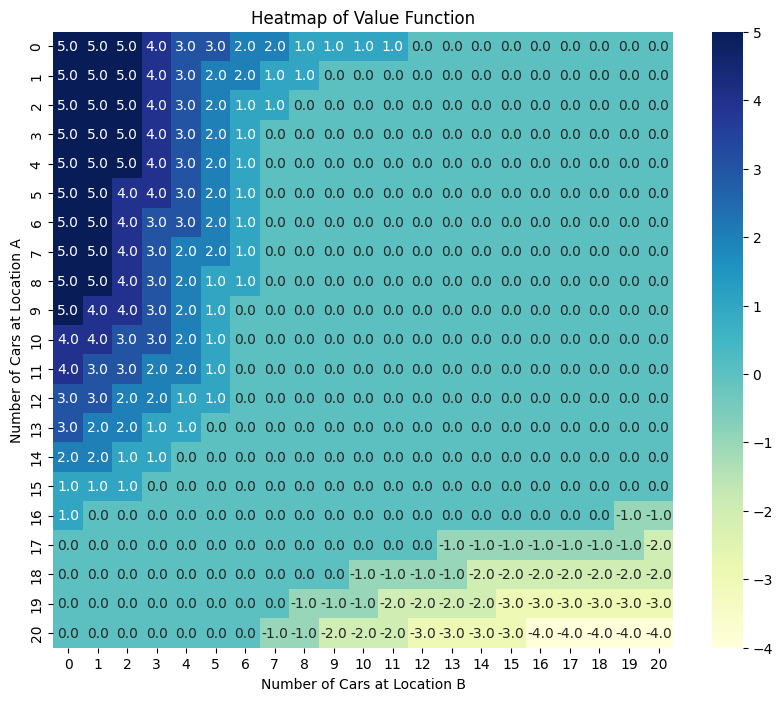

In [49]:
plt.figure(figsize=(10, 8))
sns.heatmap(np.flipud(policy), annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Heatmap of Value Function")
plt.xlabel("Number of Cars at Location B")
plt.ylabel("Number of Cars at Location A")
plt.show()

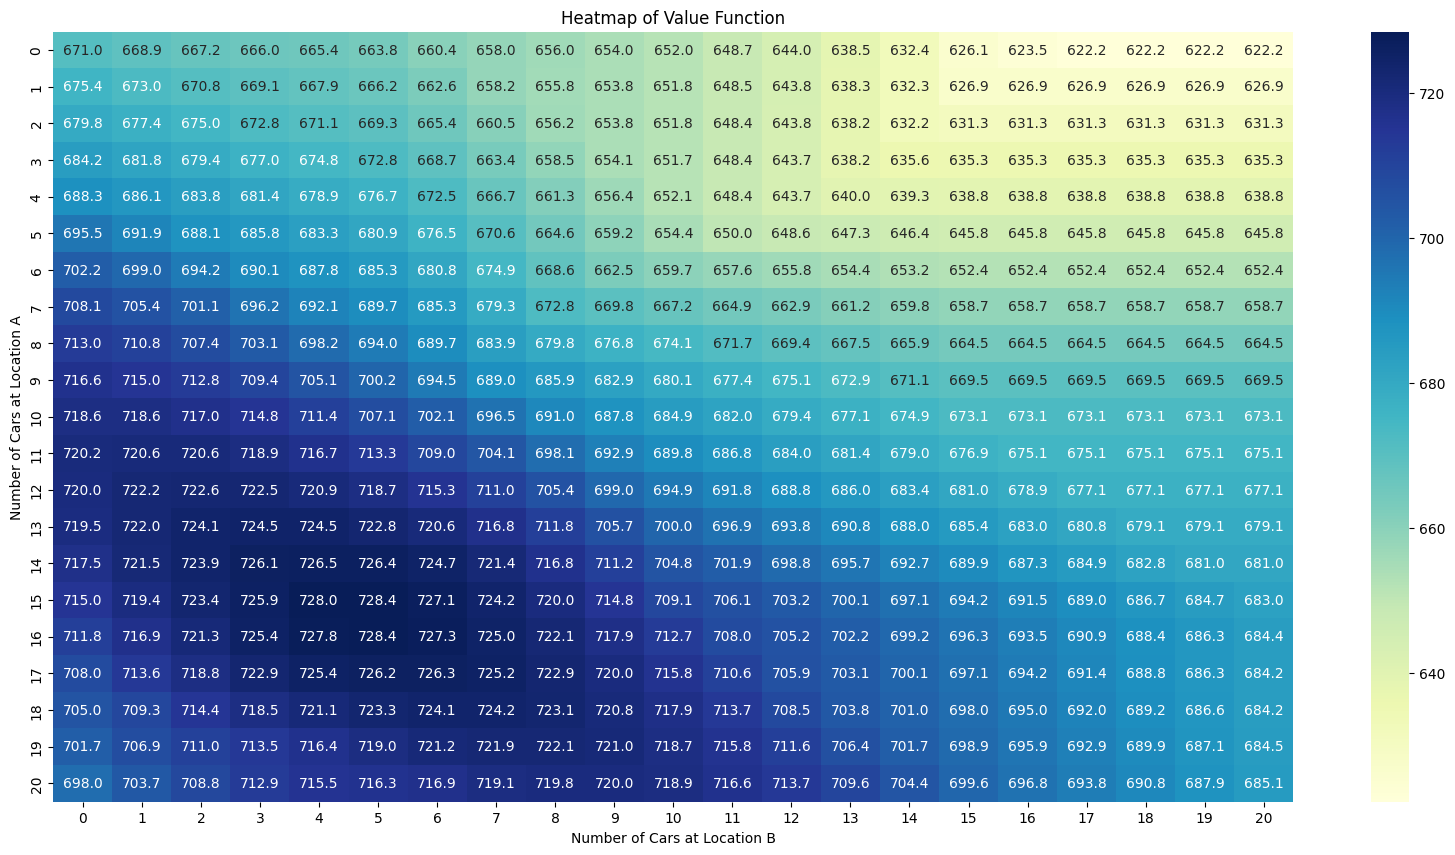

In [58]:
plt.figure(figsize=(20, 10))
sns.heatmap(np.flipud(value), annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Heatmap of Value Function")
plt.xlabel("Number of Cars at Location B")
plt.ylabel("Number of Cars at Location A")
plt.show()

*Exercise: 4.7*

In [53]:
# Calculate the reward function.
def expected_reward_new(state: tuple, action: int) -> float:
    global value
    """
    Calculate the expected reward for a given state and action.

    state: tuple, number of cars at each location.
    action: int, number of cars moved from location A to location B.
    """
    # Consider the case of the employee driving car to home for free.
    new_state = [
        max(min(jcp.max_cars, state[0] - action - 1), 0),
        max(min(jcp.max_cars, state[1] + action), 0),
    ]

    reward = jcp.reward_move * abs(action)

    # The next state (cars at the end of the next day) depends on
    # current state, action, possible requests and possible returns.
    for req_a in range(loc_a.prob_req.alpha, loc_a.prob_req.beta):
        for req_b in range(loc_b.prob_req.alpha, loc_b.prob_req.beta):
            for ret_a in range(loc_a.prob_ret.alpha, loc_a.prob_ret.beta):
                for ret_b in range(loc_b.prob_ret.alpha, loc_b.prob_ret.beta):
                    prob = (
                        loc_a.prob_req.f(req_a)
                        * loc_b.prob_req.f(req_b)
                        * loc_a.prob_ret.f(ret_a)
                        * loc_b.prob_ret.f(ret_b)
                    )

                    # Discards the cases when the no. of req > no. of cars available.
                    valid_req_a = min(req_a, new_state[0])
                    valid_req_b = min(req_b, new_state[1])

                    # Calculate the reward for the next valid state.
                    rew = jcp.reward_rent * (valid_req_a + valid_req_b)

                    # Add additional cost for the overnight parking of cars.
                    rew -= 4 * (min(new_state[0] - 10, 0) + min(new_state[1] - 10, 0))

                    # For the given requests and returns, the next state is:
                    new_s = [
                        min(jcp.max_cars, new_state[0] - valid_req_a + ret_a),
                        min(jcp.max_cars, new_state[1] - valid_req_b + ret_b),
                    ]

                    # Calculating Bellman equation.
                    reward += prob * (rew + jcp.Y * value[new_s[0], new_s[1]])

    return reward

In [50]:
def policy_evaluation_new(value, policy, eps=0.01):
    """
    Find the value function corresponding to each state for a given policy.
    """
    while True:
        delta = 0
        for i in range(jcp.max_cars + 1):
            for j in range(jcp.max_cars + 1):
                v = value[i, j]
                value[i, j] = expected_reward_new((i, j), policy[i, j])
                delta = max(delta, abs(v - value[i, j]))

        if delta < eps:
            break

    return value

In [51]:
def policy_improvement_new(policy):
    """
    Improving the policy by greedy method.
    """
    policy_stable = True
    for i in range(jcp.max_cars + 1):
        for j in range(jcp.max_cars + 1):
            old_action = policy[i, j]

            max_action_val = -np.inf
            max_action = policy[i, j]

            # Iterate over all possible actions for the state (i, j).
            move_loc1_loc2 = min(i, 5)
            move_loc2_loc1 = -min(j, 5)

            for action in range(move_loc2_loc1, move_loc1_loc2 + 1):
                action_val = expected_reward_new((i, j), action)

                if action_val > max_action_val:
                    max_action_val = action_val
                    max_action = action

            policy[i, j] = max_action

            if old_action != max_action:
                policy_stable = False

    return policy_stable, policy

In [54]:
# Implementing policyt iteration algorithm.
while True:
    policy_evaluation_new(value, policy, 5)
    policy_stable, policy = policy_improvement_new(policy)
    if policy_stable:
        break

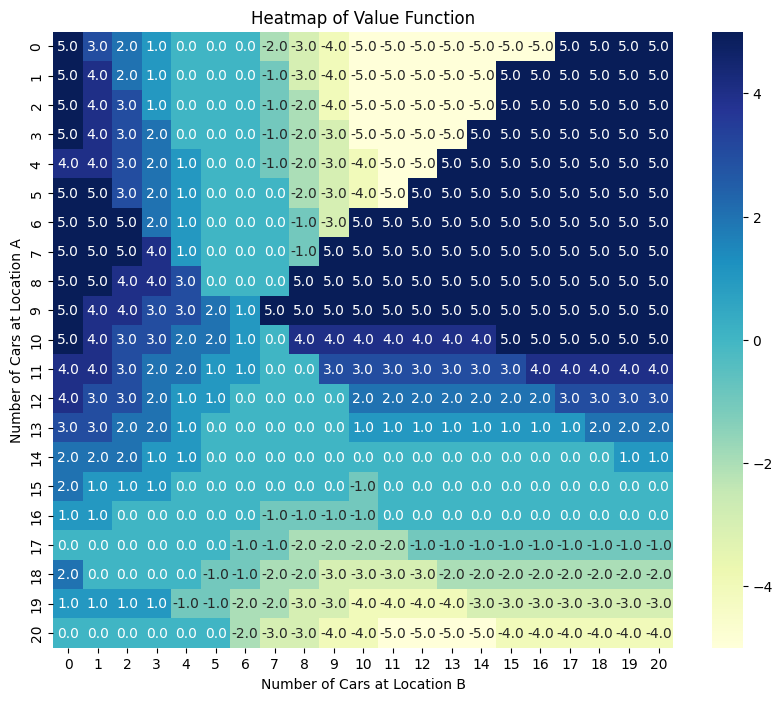

In [55]:
plt.figure(figsize=(10, 8))
sns.heatmap(np.flipud(policy), annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Heatmap of Value Function")
plt.xlabel("Number of Cars at Location B")
plt.ylabel("Number of Cars at Location A")
plt.show()

**Do it using value iteration**